In [75]:
import random
random.seed(11034601)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df = pd.read_csv("musicData.csv")
print(df.head())
print(df.shape)
df = df.dropna(subset=["music_genre"])
print(df.shape)
print(df['music_genre'].value_counts())

   instance_id           artist_name            track_name  popularity  \
0      32894.0              Röyksopp  Röyksopp's Night Out        27.0   
1      46652.0  Thievery Corporation      The Shining Path        31.0   
2      30097.0        Dillon Francis             Hurricane        28.0   
3      62177.0              Dubloadz                 Nitro        34.0   
4      24907.0           What So Not      Divide & Conquer        32.0   

   acousticness  danceability  duration_ms  energy  instrumentalness key  \
0       0.00468         0.652         -1.0   0.941           0.79200  A#   
1       0.01270         0.622     218293.0   0.890           0.95000   D   
2       0.00306         0.620     215613.0   0.755           0.01180  G#   
3       0.02540         0.774     166875.0   0.700           0.00253  C#   
4       0.00465         0.638     222369.0   0.587           0.90900  F#   

   liveness  loudness   mode  speechiness               tempo obtained_date  \
0     0.115    -5.2

In [76]:
#train test split
columns_to_drop = ['instance_id', 'artist_name', 'track_name', 'obtained_date']
df = df.drop(columns=columns_to_drop)

# Convert 'tempo' to numeric
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')

train_df = pd.DataFrame()
test_df = pd.DataFrame()

for genre in df['music_genre'].unique():
    genre_df = df[df['music_genre'] == genre]

    if len(genre_df) >= 500:
        test_sample = genre_df.sample(n=500, random_state=11034601)
        test_df = pd.concat([test_df, test_sample])
        train_df = pd.concat([train_df, genre_df.drop(test_sample.index)])
    else:
        print(f"Skipping genre '{genre}' — only {len(genre_df)} songs available.")

In [77]:
#data preprocessing for training set
# Numeric imputation (mean)
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
train_df[numeric_cols] = train_df[numeric_cols].apply(lambda col: col.fillna(col.mean()))

# Categorical imputation (mode)
categorical_cols = train_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# Map 'key' and 'mode' after imputation
key_map = {
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5,
    'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11
}
train_df['key'] = train_df['key'].map(key_map)

mode_map = {
    'Minor': 0, 'Major': 1
}
train_df['mode'] = train_df['mode'].map(mode_map)

# Calculate mean of positive durations
valid_duration_mean = train_df[train_df['duration_ms'] >= 0]['duration_ms'].mean()

# Replace negative durations with the mean
train_df['duration_ms'] = train_df['duration_ms'].apply(lambda x: valid_duration_mean if x < 0 else x)

print(train_df.shape)
print(train_df.head())


(45000, 14)
   popularity  acousticness  danceability    duration_ms  energy  \
0        27.0       0.00468         0.652  245392.799379   0.941   
1        31.0       0.01270         0.622  218293.000000   0.890   
2        28.0       0.00306         0.620  215613.000000   0.755   
4        32.0       0.00465         0.638  222369.000000   0.587   
5        47.0       0.00523         0.755  519468.000000   0.731   

   instrumentalness  key  liveness  loudness  mode  speechiness       tempo  \
0            0.7920   10     0.115    -5.201     0       0.0748  100.889000   
1            0.9500    2     0.124    -7.043     0       0.0300  115.002000   
2            0.0118    8     0.534    -4.617     1       0.0345  127.994000   
4            0.9090    6     0.157    -6.266     1       0.0413  145.036000   
5            0.8540    2     0.216   -10.517     0       0.0412  119.994344   

   valence music_genre  
0    0.759  Electronic  
1    0.531  Electronic  
2    0.333  Electronic  
4   

In [78]:
#data preprocessing for testing set
# Numeric imputation (mean)
numeric_cols = test_df.select_dtypes(include=['float64', 'int64']).columns
test_df[numeric_cols] = test_df[numeric_cols].apply(lambda col: col.fillna(col.mean()))

# Categorical imputation (mode)
categorical_cols = test_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

# Map 'key' and 'mode' after imputation
key_map = {
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5,
    'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11
}
test_df['key'] = test_df['key'].map(key_map)

mode_map = {
    'Minor': 0, 'Major': 1
}
test_df['mode'] = test_df['mode'].map(mode_map)

# Calculate mean of positive durations
valid_duration_mean = test_df[test_df['duration_ms'] >= 0]['duration_ms'].mean()

# Replace negative durations with the mean
test_df['duration_ms'] = test_df['duration_ms'].apply(lambda x: valid_duration_mean if x < 0 else x)

print(test_df.shape)
print(test_df.head())


(5000, 14)
      popularity  acousticness  danceability  duration_ms  energy  \
2091        32.0       0.11800         0.253     240969.0   0.601   
4849        42.0       0.15000         0.837     321791.0   0.378   
1425        32.0       0.04580         0.570     160993.0   0.553   
4590        44.0       0.43300         0.543     251440.0   0.480   
4439        23.0       0.00301         0.708     365533.0   0.894   

      instrumentalness  key  liveness  loudness  mode  speechiness    tempo  \
2091           0.00489    7     0.232    -5.379     1       0.0448  149.804   
4849           0.87400    2     0.102   -11.063     1       0.0615  104.995   
1425           0.00000    0     0.278    -4.666     1       0.4230  170.654   
4590           0.88600    2     0.117   -14.551     1       0.0304  159.969   
4439           0.61200   11     0.196    -6.531     0       0.0478  129.998   

      valence music_genre  
2091   0.0683  Electronic  
4849   0.3170  Electronic  
1425   0.6010  

In [79]:
print(test_df['music_genre'].value_counts())


music_genre
Electronic     500
Anime          500
Jazz           500
Alternative    500
Country        500
Rap            500
Blues          500
Rock           500
Classical      500
Hip-Hop        500
Name: count, dtype: int64


In [80]:
# Separate features and targets
X_train = train_df.drop(columns=['music_genre'])
y_train = train_df['music_genre']

X_test = test_df.drop(columns=['music_genre'])
y_test = test_df['music_genre']

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

#Define categorical columns to exclude from PCA
categorical_cols = ['key', 'mode']

# Separate numeric and categorical parts
X_train_num = X_train.drop(columns=categorical_cols)
X_test_num = X_test.drop(columns=categorical_cols)

#Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

#Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#Add back categorical features (key and mode)
X_train_final = np.hstack([X_train_pca, X_train[categorical_cols].values])
X_test_final = np.hstack([X_test_pca, X_test[categorical_cols].values])


print("PCA components:", pca.n_components_)
print("Explained variance ratio:", round(sum(pca.explained_variance_ratio_), 4))
print("Final training set shape:", X_train_final.shape)
print("Final test set shape:", X_test_final.shape)


✅ PCA components: 9
✅ Explained variance ratio: 0.9667
✅ Final training set shape: (45000, 11)
✅ Final test set shape: (5000, 11)


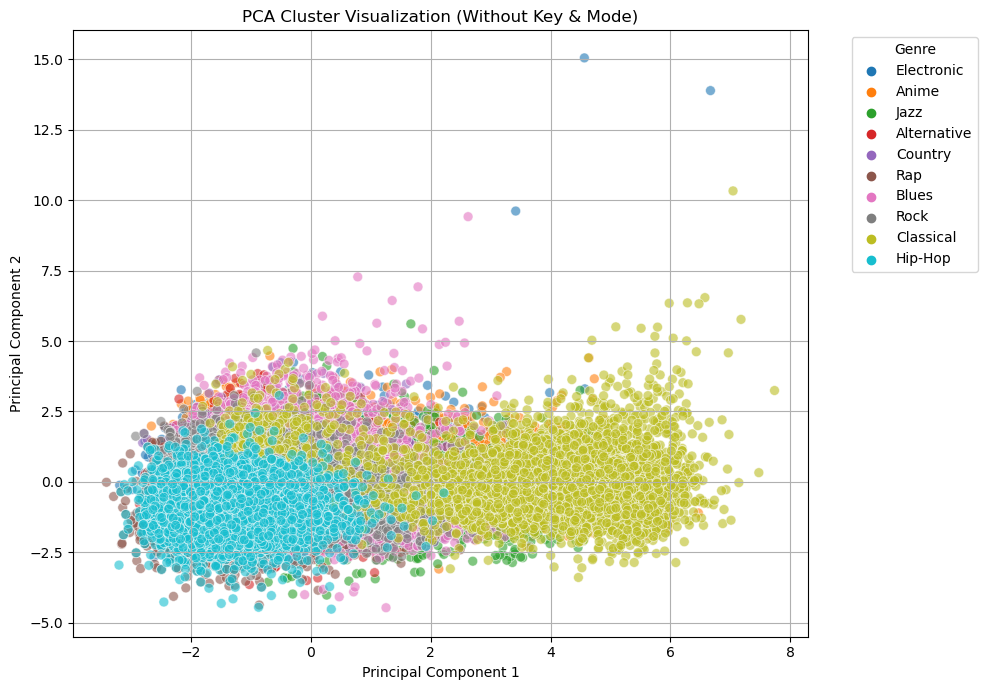

In [87]:
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=["PC1", "PC2"])
pca_df["Genre"] = y_train.values  # y_train should be the genre labels

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Genre",
    palette="tab10",
    alpha=0.6,
    s=50
)

plt.title("PCA Cluster Visualization (Without Key & Mode)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Genre")
plt.grid(True)
plt.tight_layout()
plt.show()

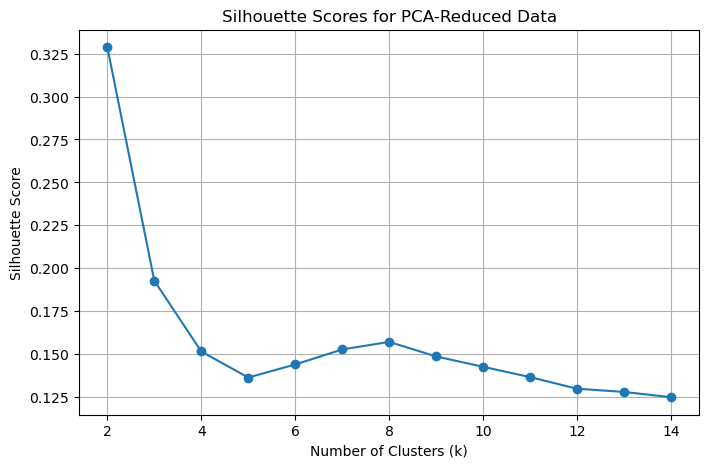

Best number of clusters: 2 (Silhouette Score = 0.329)


In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Evaluate silhouette scores for k between 2 and 14
silhouette_scores = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=11034601)
    labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for PCA-Reduced Data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Print best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best number of clusters: {best_k} (Silhouette Score = {max(silhouette_scores):.3f})")


In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode genre labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train Random Forest classifier
rf_clf = OneVsRestClassifier(RandomForestClassifier(
    n_estimators=200, random_state=11034601, n_jobs=-1))
rf_clf.fit(X_train_final, y_train_encoded)

# Predictions
y_rf_pred = rf_clf.predict(X_test_final)
y_rf_proba = rf_clf.predict_proba(X_test_final)

# Evaluate
rf_acc = accuracy_score(y_test_encoded, y_rf_pred)
rf_auc = roc_auc_score(y_test_encoded, y_rf_proba, multi_class='ovr', average='macro')

print("Random Forest Accuracy:", round(rf_acc, 4))
print("Random Forest Macro-AUC:", round(rf_auc, 4))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_rf_pred, target_names=label_encoder.classes_))


Random Forest Accuracy: 0.5158
Random Forest Macro-AUC: 0.9025

Classification Report:
               precision    recall  f1-score   support

 Alternative       0.39      0.32      0.35       500
       Anime       0.72      0.67      0.69       500
       Blues       0.54      0.52      0.53       500
   Classical       0.83      0.83      0.83       500
     Country       0.50      0.51      0.50       500
  Electronic       0.58      0.59      0.58       500
     Hip-Hop       0.34      0.38      0.36       500
        Jazz       0.50      0.48      0.49       500
         Rap       0.32      0.27      0.29       500
        Rock       0.46      0.58      0.51       500

    accuracy                           0.52      5000
   macro avg       0.52      0.52      0.51      5000
weighted avg       0.52      0.52      0.51      5000



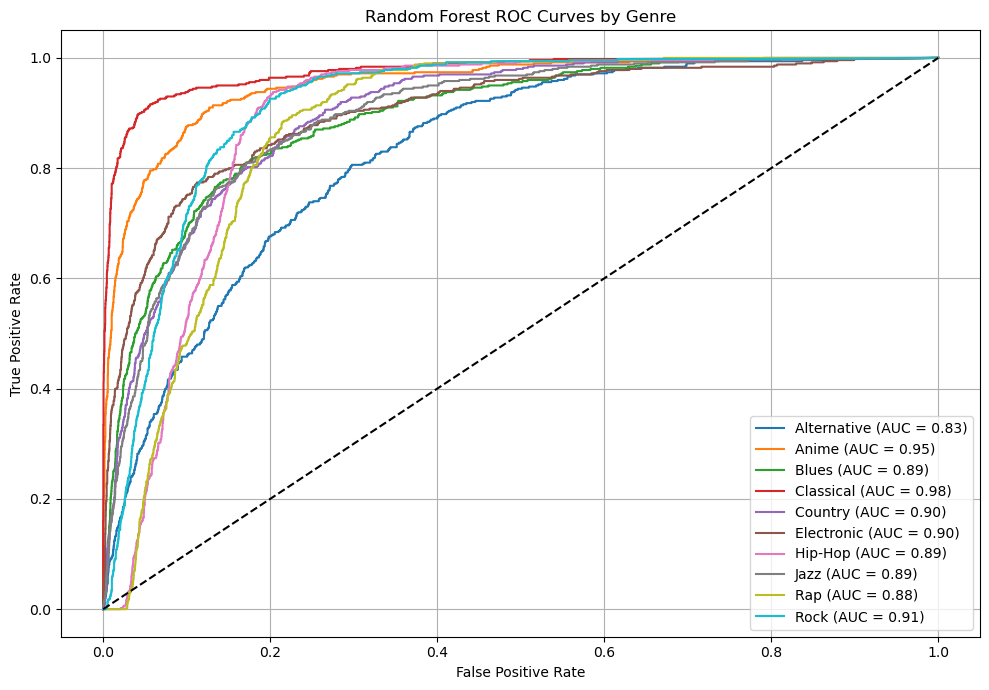

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for each class
plt.figure(figsize=(10, 7))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve((y_test_encoded == i).astype(int), y_rf_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Random Forest ROC Curves by Genre")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [93]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [94]:
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train XGBoost classifier with One-vs-Rest strategy
xgb_clf = OneVsRestClassifier(XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=11034601
))

xgb_clf.fit(X_train_final, y_train_encoded)

# Predictions
y_xgb_pred = xgb_clf.predict(X_test_final)
y_xgb_proba = xgb_clf.predict_proba(X_test_final)

# Evaluation
xgb_acc = accuracy_score(y_test_encoded, y_xgb_pred)
xgb_auc = roc_auc_score(y_test_encoded, y_xgb_proba, multi_class='ovr', average='macro')

print("XGBoost Accuracy:", round(xgb_acc, 4))
print("XGBoost Macro-AUC:", round(xgb_auc, 4))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_xgb_pred, target_names=label_encoder.classes_))


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [23:34:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [23:35:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.5386
XGBoost Macro-AUC: 0.9167

Classification Report:
               precision    recall  f1-score   support

 Alternative       0.40      0.32      0.36       500
       Anime       0.75      0.69      0.72       500
       Blues       0.56      0.52      0.54       500
   Classical       0.85      0.82      0.83       500
     Country       0.51      0.56      0.53       500
  Electronic       0.61      0.61      0.61       500
     Hip-Hop       0.39      0.44      0.41       500
        Jazz       0.51      0.49      0.50       500
         Rap       0.36      0.32      0.34       500
        Rock       0.48      0.62      0.54       500

    accuracy                           0.54      5000
   macro avg       0.54      0.54      0.54      5000
weighted avg       0.54      0.54      0.54      5000



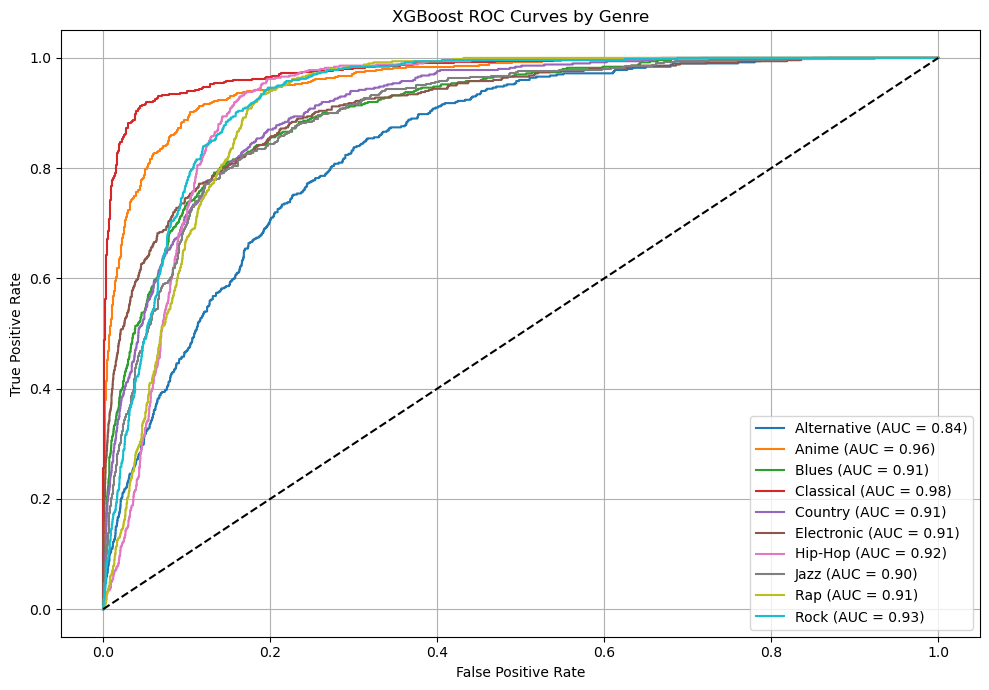

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve((y_test_encoded == i).astype(int), y_xgb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("XGBoost ROC Curves by Genre")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [96]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train a Multi-layer Perceptron (Neural Network)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=11034601
)
mlp.fit(X_train_final, y_train_encoded)

# Predict
y_mlp_pred = mlp.predict(X_test_final)
y_mlp_proba = mlp.predict_proba(X_test_final)

# Evaluate
mlp_acc = accuracy_score(y_test_encoded, y_mlp_pred)
mlp_auc = roc_auc_score(y_test_encoded, y_mlp_proba, multi_class='ovr', average='macro')

print("MLP Accuracy:", round(mlp_acc, 4))
print("MLP Macro-AUC:", round(mlp_auc, 5))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_mlp_pred, target_names=label_encoder.classes_))


MLP Accuracy: 0.5614
MLP Macro-AUC: 0.92355

Classification Report:
               precision    recall  f1-score   support

 Alternative       0.40      0.40      0.40       500
       Anime       0.76      0.75      0.75       500
       Blues       0.59      0.49      0.53       500
   Classical       0.84      0.82      0.83       500
     Country       0.57      0.51      0.54       500
  Electronic       0.62      0.64      0.63       500
     Hip-Hop       0.44      0.32      0.37       500
        Jazz       0.52      0.51      0.52       500
         Rap       0.44      0.51      0.47       500
        Rock       0.48      0.66      0.56       500

    accuracy                           0.56      5000
   macro avg       0.56      0.56      0.56      5000
weighted avg       0.56      0.56      0.56      5000



/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


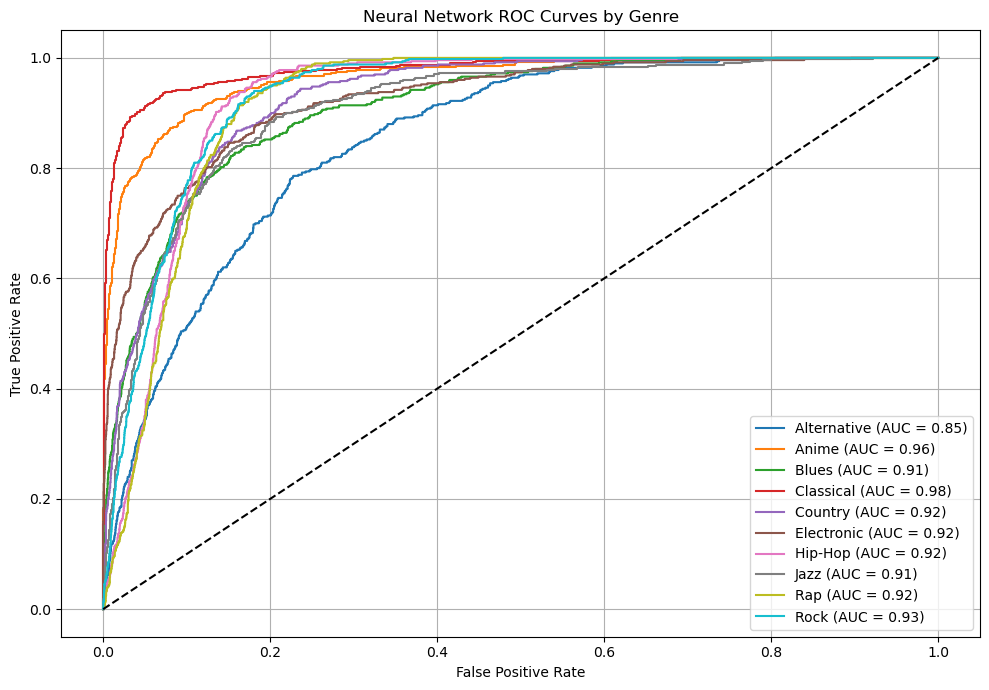

In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve((y_test_encoded == i).astype(int), y_mlp_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Neural Network ROC Curves by Genre")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


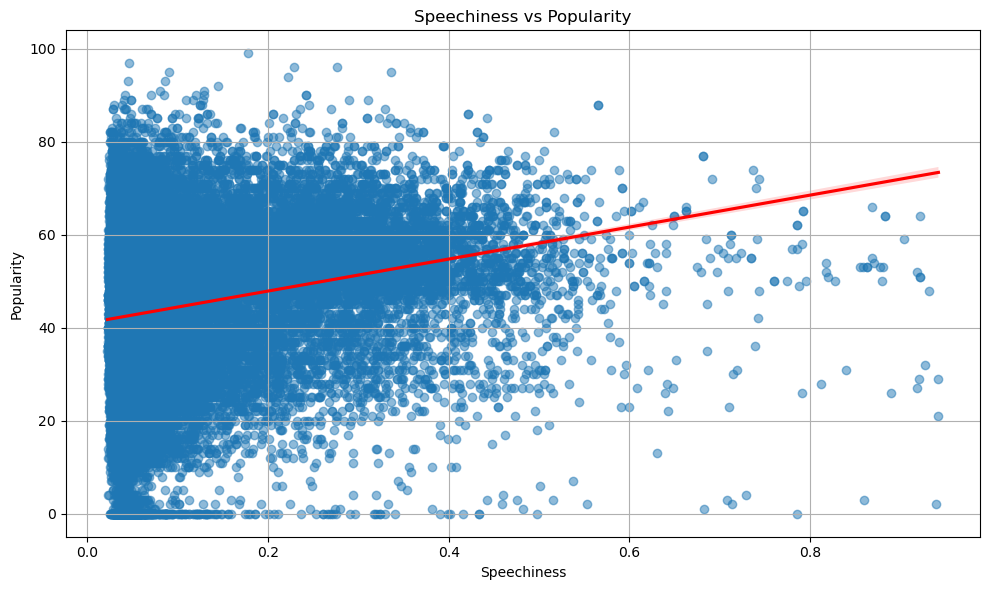

Correlation between speechiness and popularity: 0.2243
Linear Regression Results:
Intercept: 41.0020
Coefficient: 34.3900
R-squared: 0.0503


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


# Drop rows with missing values in relevant columns
df_clean = df[['speechiness', 'popularity']].dropna()

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='speechiness', y='popularity',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title("Speechiness vs Popularity")
plt.xlabel("Speechiness")
plt.ylabel("Popularity")
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation
corr = df_clean['speechiness'].corr(df_clean['popularity'])
print(f"Correlation between speechiness and popularity: {corr:.4f}")

# Linear regression model
X = df_clean[['speechiness']]
y = df_clean['popularity']
model = LinearRegression().fit(X, y)
r_squared = model.score(X, y)

print("Linear Regression Results:")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"R-squared: {r_squared:.4f}")
